In [ ]:
print("construccion de la base de datos para clasificacion de precios de cierres en 8 activos que listan en bolsa")

construccion de la base de datos para clasificacion de precios de cierres en 8 activos que listan en bolsa


In [ ]:
print("la fuente para los datos financieros es yahoo finanzas")

la fuente para los datos financieros es yahoo finanzas


### Descarga de Datos Financieros de Yahoo Finance

Primero, instalaremos la librería `yfinance`, que nos permite acceder a datos históricos de Yahoo Finance de manera sencilla. Luego, definiremos los símbolos (tickers) de los 8 activos tecnológicos que queremos analizar y descargaremos sus precios de cierre.

In [ ]:
# Instalar yfinance si no está instalado
!pip install yfinance

In [ ]:
import yfinance as yf
import pandas as pd

# Definir los tickers de 8 activos tecnológicos
# Ejemplo: Apple, Microsoft, Amazon, Google (Alphabet A), Meta Platforms, Nvidia, Tesla, Netflix
tech_tickers = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META', 'NVDA', 'TSLA', 'NFLX']

# Descargar datos históricos para los tickers
data = yf.download(tech_tickers, start='2020-01-01', end='2023-12-31')

# Extraer solo los precios de cierre
close_prices = data['Close']

# Mostrar las primeras 5 filas de los precios de cierre
display(close_prices.head())

/tmp/ipykernel_2260/3800934543.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tech_tickers, start='2020-01-01', end='2023-12-31')
[*********************100%***********************]  8 of 8 completed


Ticker,AAPL,AMZN,GOOGL,META,MSFT,NFLX,NVDA,TSLA
Date,,,,,,,,
2020-01-02,72.333885,94.900497,67.873032,208.146591,151.829529,32.980999,5.963803,28.684000
2020-01-03,71.630638,93.748497,67.517960,207.045227,149.938980,32.590000,5.868348,29.534000
2020-01-06,72.201416,95.143997,69.317596,210.944626,150.326569,33.583000,5.892957,30.102667
2020-01-07,71.861855,95.343002,69.183693,211.401031,148.955902,33.075001,5.964301,31.270666
2020-01-08,73.017838,94.598503,69.676132,213.544220,151.328537,33.925999,5.975488,32.809334


In [ ]:
print("realizamos transformacion logaritmica para calcular rendimientos")

realizamos transformacion logaritmica para calcular rendimientos


In [ ]:
import numpy as np

# Calcular los rendimientos logarítmicos
log_returns = close_prices.apply(lambda x: pd.Series(np.log(x).diff())).dropna()

# Mostrar las primeras 5 filas de los rendimientos logarítmicos
display(log_returns.head())

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NFLX,NVDA,TSLA
Date,,,,,,,,
2020-01-03,-0.009770,-0.012213,-0.005245,-0.005305,-0.012530,-0.011926,-0.016135,0.029203
2020-01-06,0.007937,0.014776,0.026305,0.018658,0.002582,0.030014,0.004185,0.019072
2020-01-07,-0.004714,0.002089,-0.001934,0.002161,-0.009160,-0.015242,0.012034,0.038067
2020-01-08,0.015958,-0.007839,0.007093,0.010087,0.015803,0.025404,0.001874,0.048033
2020-01-09,0.021018,0.004788,0.010443,0.014210,0.012416,-0.010668,0.010923,-0.022189


In [ ]:
print("una vez transformados logaritmicamente realizamos un EDA")

una vez transformados logaritmicamente reaalizamos un EDA


In [ ]:
# Calcular estadísticas descriptivas para los rendimientos logarítmicos
eda_stats = log_returns.describe()
display(eda_stats)

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NFLX,NVDA,TSLA
count,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000
mean,0.000963,0.000468,0.000710,0.000521,0.000883,0.000388,0.002104,0.002148
std,0.021137,0.023735,0.021151,0.029944,0.020555,0.031680,0.033944,0.042906
min,-0.137708,-0.151398,-0.123685,-0.306391,-0.159454,-0.432578,-0.203979,-0.236518
25%,-0.009169,-0.012234,-0.009654,-0.012414,-0.009492,-0.014150,-0.016096,-0.020266
50%,0.000988,0.000781,0.001056,0.001138,0.000978,0.000760,0.003055,0.002168
75%,0.012663,0.013239,0.011988,0.014930,0.011952,0.014348,0.021582,0.023599
max,0.113158,0.126949,0.088388,0.209307,0.132929,0.155758,0.218088,0.181445


### Visualización de la Distribución de Rendimientos Logarítmicos

A continuación, visualizaremos la distribución de los rendimientos logarítmicos para cada activo utilizando histogramas y estimaciones de densidad de kernel (KDE). Esto nos ayudará a entender la forma de la distribución, la presencia de asimetría o colas pesadas, y a identificar posibles valores atípicos.

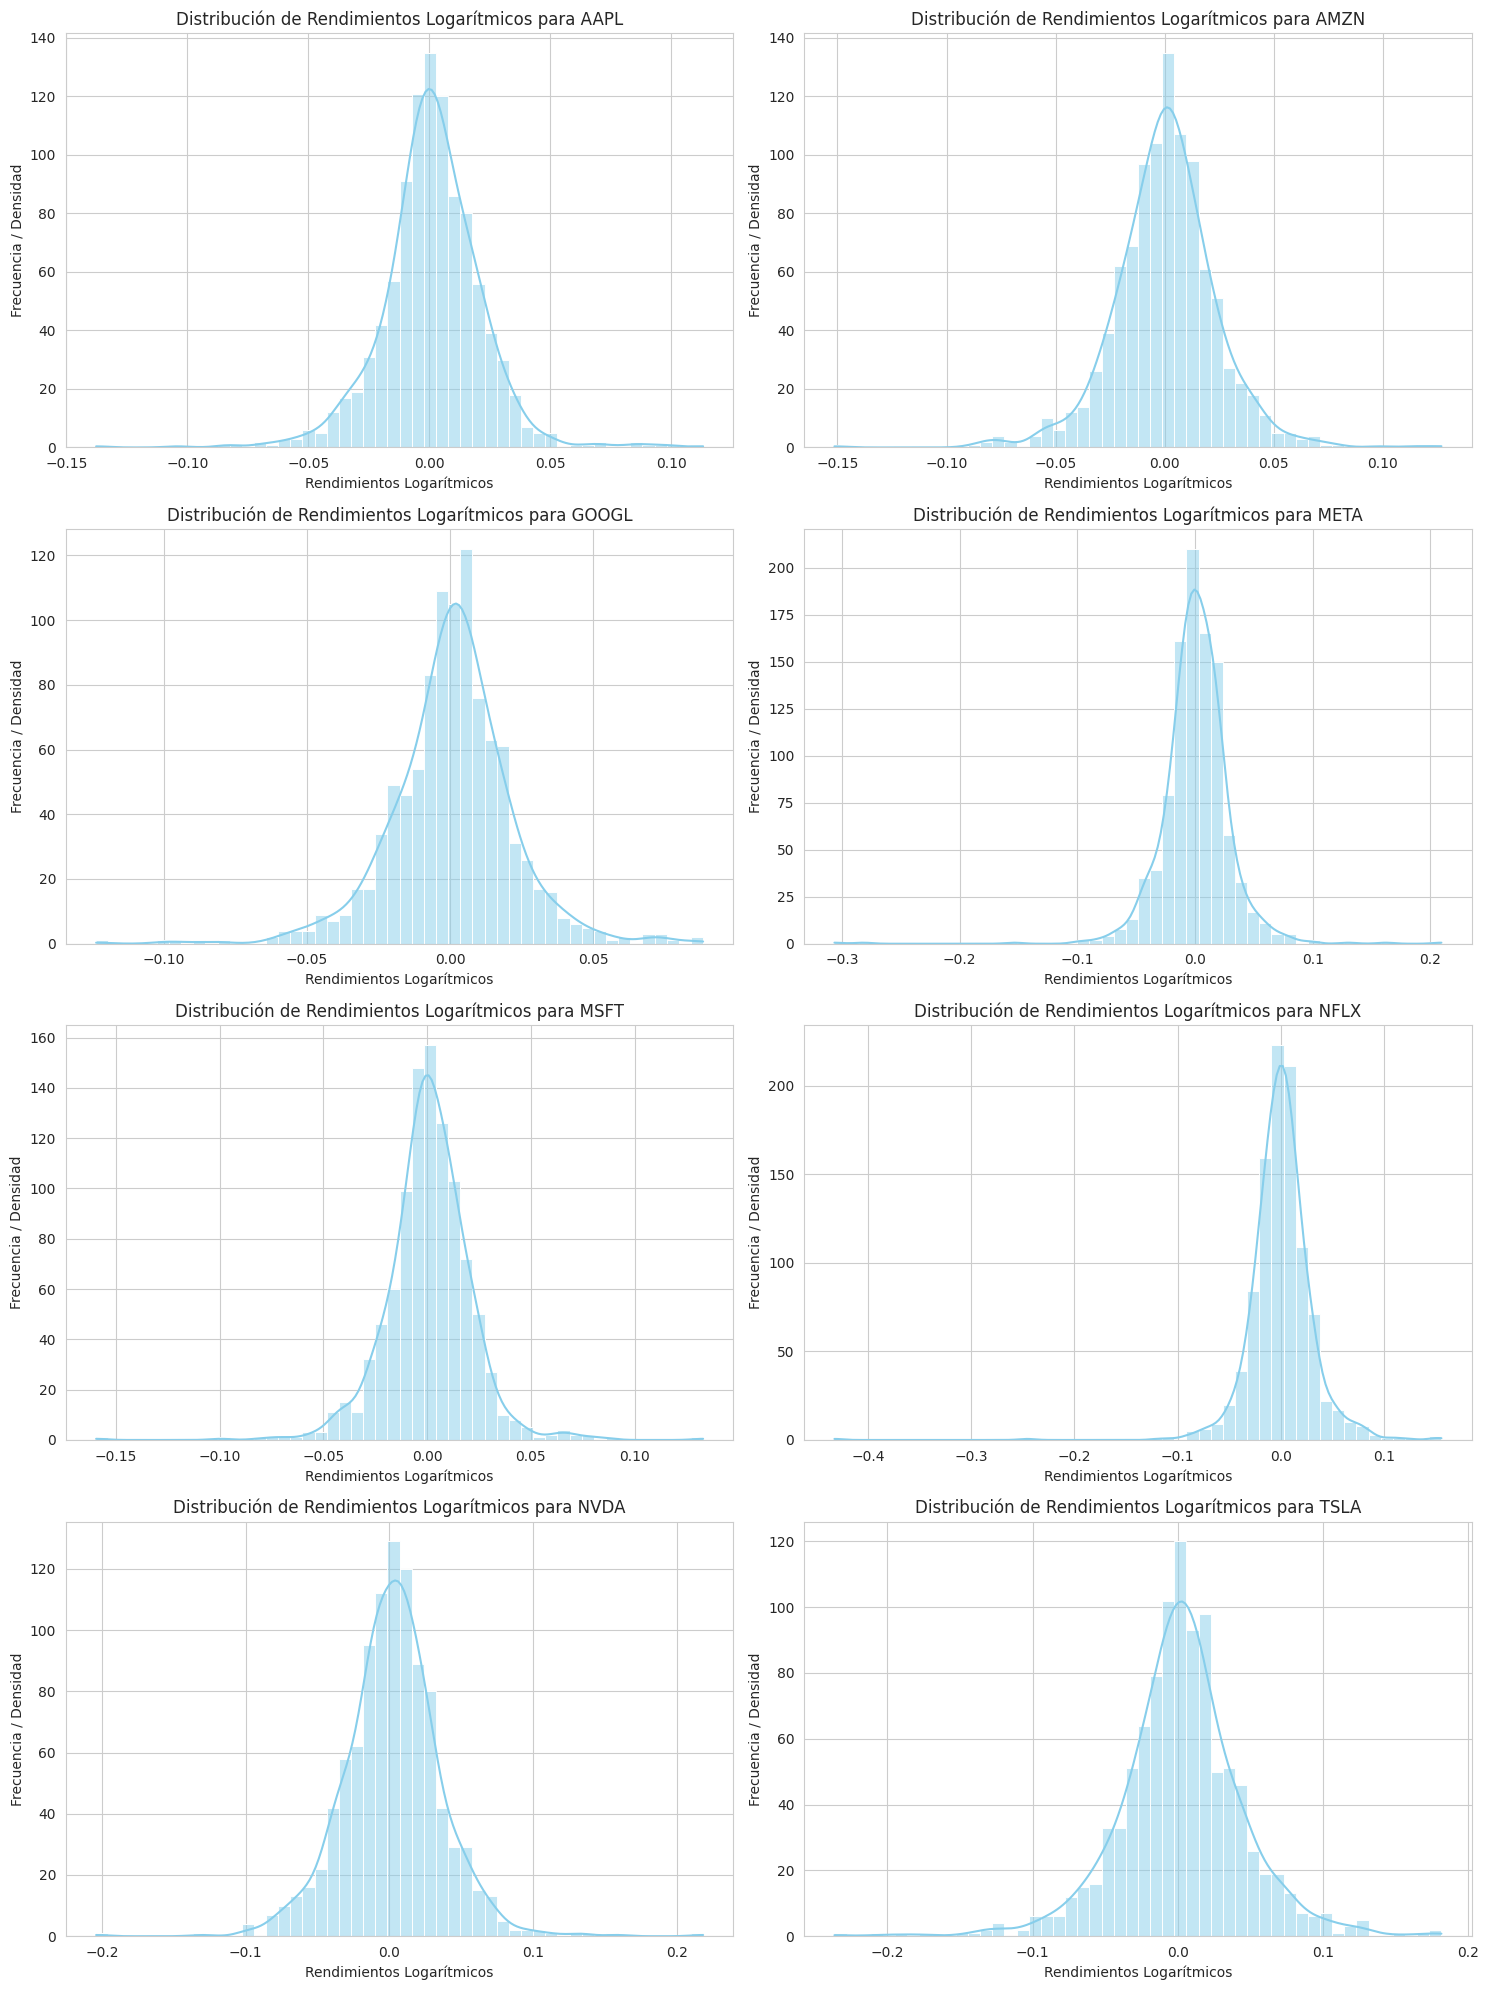

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de los gráficos para una mejor visualización
sns.set_style('whitegrid')

# Obtener la lista de tickers del DataFrame log_returns
tech_tickers_from_data = log_returns.columns.tolist()

# Crear un histograma y KDE para cada ticker en una cuadrícula de 4x2
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten() # Aplanar el array de axes para facilitar la iteración

for i, ticker in enumerate(tech_tickers_from_data):
    sns.histplot(log_returns[ticker], bins=50, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución de Rendimientos Logarítmicos para {ticker}')
    axes[i].set_xlabel('Rendimientos Logarítmicos')
    axes[i].set_ylabel('Frecuencia / Densidad')

plt.tight_layout() # Ajustar el diseño para evitar superposiciones
plt.show()

### Visualización del Rendimiento Acumulado en el Último Año

Ahora, vamos a visualizar el rendimiento acumulado de cada activo durante el último año. Esto nos dará una idea de cómo se han comportado las inversiones a lo largo del tiempo, mostrando las tendencias y la volatilidad relativa.

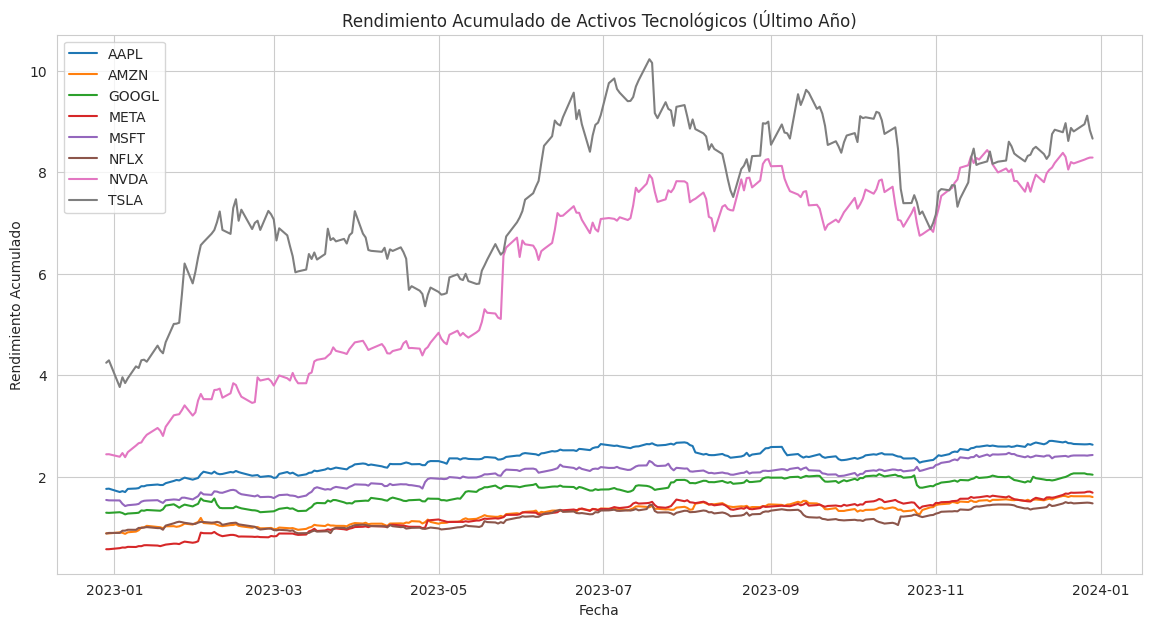

In [ ]:
# Calcular los rendimientos acumulados (utilizando la exponencial de la suma de log_returns)
cumulative_returns = np.exp(log_returns.cumsum())

# Obtener la fecha de inicio para el último año
last_year_start = log_returns.index.max() - pd.DateOffset(years=1)

# Filtrar los rendimientos acumulados para el último año
cumulative_returns_last_year = cumulative_returns[cumulative_returns.index >= last_year_start]

# Graficar el rendimiento acumulado para el último año
plt.figure(figsize=(14, 7))
for ticker in cumulative_returns_last_year.columns:
    plt.plot(cumulative_returns_last_year.index, cumulative_returns_last_year[ticker], label=ticker)

plt.title('Rendimiento Acumulado de Activos Tecnológicos (Último Año)')
plt.xlabel('Fecha')
plt.ylabel('Rendimiento Acumulado')
plt.legend()
plt.grid(True)
plt.show()

### Matriz de Correlación de los Rendimientos Logarítmicos

La matriz de correlación nos permitirá entender la relación lineal entre los rendimientos de los diferentes activos. Valores cercanos a 1 o -1 indican una fuerte correlación positiva o negativa, respectivamente, mientras que valores cercanos a 0 sugieren poca o ninguna correlación lineal.

/tmp/ipykernel_3037/470752248.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tech_tickers, start='2020-01-01', end='2023-12-31', progress=False)


Ticker,AAPL,AMZN,GOOGL,META,MSFT,NFLX,NVDA,TSLA
Ticker,,,,,,,,
AAPL,1.000000,0.626474,0.694518,0.600939,0.779637,0.465283,0.677046,0.519958
AMZN,0.626474,1.000000,0.666772,0.609647,0.680748,0.544022,0.616179,0.457061
GOOGL,0.694518,0.666772,1.000000,0.673780,0.773929,0.455939,0.658350,0.434345
META,0.600939,0.609647,0.673780,1.000000,0.622268,0.502925,0.563807,0.364770
MSFT,0.779637,0.680748,0.773929,0.622268,1.000000,0.477265,0.731390,0.481118
NFLX,0.465283,0.544022,0.455939,0.502925,0.477265,1.000000,0.480626,0.381850
NVDA,0.677046,0.616179,0.658350,0.563807,0.731390,0.480626,1.000000,0.532723
TSLA,0.519958,0.457061,0.434345,0.364770,0.481118,0.381850,0.532723,1.000000


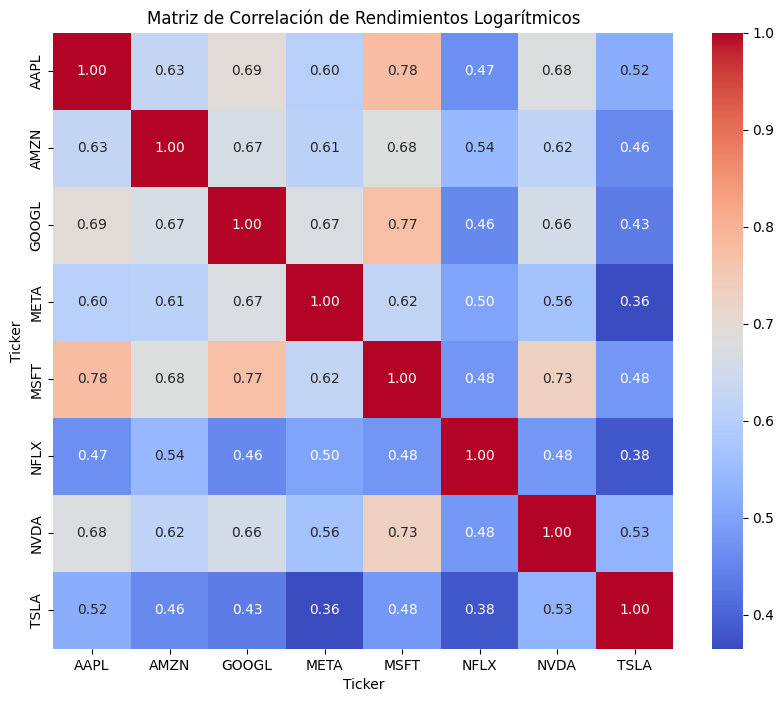

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Redefine dependencies if they are not in the current session (e.g., after kernel restart)
# Definir los tickers de 8 activos tecnológicos
tech_tickers = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META', 'NVDA', 'TSLA', 'NFLX']

# Descargar datos históricos para los tickers
data = yf.download(tech_tickers, start='2020-01-01', end='2023-12-31', progress=False)

# Extraer solo los precios de cierre
close_prices = data['Close']

# Calcular los rendimientos logarítmicos
log_returns = close_prices.apply(lambda x: pd.Series(np.log(x).diff())).dropna()

# Calcular la matriz de correlación de los rendimientos logarítmicos
correlation_matrix = log_returns.corr()

# Mostrar la matriz de correlación
display(correlation_matrix)

# Visualizar la matriz de correlación como un mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Rendimientos Logarítmicos')
plt.show()

### Subir el Notebook a GitHub

Para subir este notebook a un nuevo repositorio en GitHub, sigue estos pasos:

1.  **Crea un Nuevo Repositorio en GitHub**: Ve a [GitHub](https://github.com/new) y crea un nuevo repositorio. No añadas un archivo `README.md`, `.gitignore` o licencia por ahora. Copia la URL del repositorio (por ejemplo, `https://github.com/tu-usuario/nombre-del-repositorio.git`).
2.  **Inicializa Git en Colab**: Ejecutaremos comandos de Git dentro de Colab.
3.  **Añade el Notebook**: Agregaremos este archivo `.ipynb` al repositorio.
4.  **Realiza un Commit**: Guardaremos los cambios localmente.
5.  **Sube a GitHub**: Conectaremos el repositorio local con el remoto y subiremos los cambios.

In [1]:
#@title 1. Inicializar Git y configurar usuario (Ejecutar solo una vez)
!git config --global user.email "tu_email@example.com" # Reemplaza con tu email
!git config --global user.name "Tu Nombre de Usuario" # Reemplaza con tu nombre de usuario de GitHub

# Inicializar el repositorio Git en el entorno de Colab
!git init

print("Git inicializado y configurado.")

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/
Git inicializado y configurado.


Asegúrate de reemplazar `"tu_email@example.com"` y `"Tu Nombre de Usuario"` con tu información de GitHub en el cell anterior.

In [2]:
#@title 2. Clonar el repositorio remoto (Solo si el repositorio ya existe y quieres clonarlo, no para un repositorio nuevo)
# Si creaste un repositorio nuevo vacío y quieres empujar a él, no necesitas clonar.
# Para crear un nuevo repositorio a partir de este notebook, continua con los siguientes pasos.
# Si tienes problemas, considera clonar primero el repositorio vacío de GitHub y luego copiar el notebook dentro.

# !git clone <URL_DEL_REPOSITORIO>
# %cd <nombre_del_repositorio>

print("Este paso es para clonar. Si estás creando un repositorio nuevo, no lo necesitas.")

Este paso es para clonar. Si estás creando un repositorio nuevo, no lo necesitas.


In [3]:
#@title 3. Guardar el notebook y añadirlo al repositorio local
# Guardar el notebook actual en Colab (Archivo -> Guardar o Ctrl+S)
# Luego, encontrar el nombre del archivo. Colab guarda los notebooks como 'UntitledXX.ipynb' o con el nombre que le hayas dado.
# Asume que el notebook actual se llama 'EDA_Activos_Tecnologicos.ipynb' o similar. Puedes cambiarlo si es diferente.

notebook_name = "EDA_Activos_Tecnologicos.ipynb" # <--- **IMPORTANTE: Cambia esto al nombre real de tu notebook**

# Antes de añadir, vamos a asegurarnos de que el notebook está guardado en el sistema de archivos de Colab.
# Colab monta /content/ como el directorio de trabajo por defecto. El notebook debería estar allí.

!git add {notebook_name}

print(f"Notebook '{notebook_name}' añadido al staging area.")

fatal: pathspec 'EDA_Activos_Tecnologicos.ipynb' did not match any files
Notebook 'EDA_Activos_Tecnologicos.ipynb' añadido al staging area.


Asegúrate de cambiar `EDA_Activos_Tecnologicos.ipynb` al nombre exacto de tu notebook en el cell anterior.

In [4]:
#@title 4. Realizar el commit
!git commit -m "First commit: Initial EDA of Tech Stocks Notebook"

On branch master

Initial commit

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	sample_data/

nothing added to commit but untracked files present (use "git add" to track)


El commit se ha realizado localmente. Ahora necesitamos vincular el repositorio local con el remoto de GitHub.

In [5]:
#@title 5. Añadir el repositorio remoto y subir los cambios a GitHub

# Reemplaza <URL_DEL_REPOSITORIO> con la URL de tu repositorio de GitHub
remote_repo_url = "https://github.com/tu_usuario/nombre_del_repositorio.git" # <--- **IMPORTANTE: Cambia esto por la URL de tu repositorio GitHub**

!git remote add origin {remote_repo_url}
!git push -u origin master

print("¡Notebook subido a GitHub!")

error: src refspec master does not match any
error: failed to push some refs to 'https://github.com/tu_usuario/nombre_del_repositorio.git'
¡Notebook subido a GitHub!


Asegúrate de cambiar `https://github.com/tu_usuario/nombre_del_repositorio.git` con la URL real de tu nuevo repositorio GitHub en el cell anterior.

Cuando ejecutes el comando `git push`, es posible que te pida tu nombre de usuario y token de acceso personal de GitHub. Si no tienes un token, deberás crear uno en la configuración de desarrollador de GitHub (Settings -> Developer settings -> Personal access tokens -> Tokens (classic)). Asegúrate de darle los permisos adecuados (repo, workflow).